# S2S Model Sandbox
-------------------


In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchinfo

import seaborn as sns

# from utility import read_and_write


# Data Generation

---


In [13]:
def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def spectrum_generation(number_of_grid_points, peak_setting, variation_setting, normalization=True, random_seed=999):
    # create perfect spectrum
    # initiation
    grid = np.linspace(0, 1, number_of_grid_points) 
    total_intensity = np.zeros(number_of_grid_points)
    df = pd.DataFrame({'BE': grid, 'I': np.zeros(number_of_grid_points)})
    for setting in peak_setting:
        if setting['type'] == 'gaussian':
            center = setting['p1']
            sigma = setting['p2']
            scaling = setting['scaling']
            total_intensity += scaling*gaussian(grid, center, sigma)
        elif setting['type'] == 'linear':
            slope = setting['p1']
            shift = setting['p2']
            total_intensity += grid*slope+shift
        else:
            Exception('Unknown type for spectrum generation')
    df['I'] = total_intensity

    # create variated spectrum
    # initiation
    total_intensity = np.zeros(number_of_grid_points)
    x_shift = 0
    x_stretch = 1
    for setting in variation_setting:
        if setting['type'] == 'shift':
            x_shift = setting['p1']
        if setting['type'] == 'stretch':
            x_stretch = setting['p1']
            x_stretch_center = setting['p2']
        if setting['type'] == 'noise':
            total_intensity += np.random.default_rng(seed=random_seed).uniform(size=number_of_grid_points, low=-setting['p1'], high=setting['p1'])

    # create perfect spectrum
    df_variated = pd.DataFrame({'BE': grid, 'I': np.zeros(number_of_grid_points)})
    for setting in peak_setting:
        if setting['type'] == 'gaussian':
            center = setting['p1']
            sigma = setting['p2']
            scaling = setting['scaling']
            total_intensity += scaling*gaussian((grid-x_stretch_center)/x_stretch+x_stretch_center-x_shift, center, sigma)
        elif setting['type'] == 'linear':
            slope = setting['p1']
            shift = setting['p2']
            total_intensity += ((grid-x_stretch_center)/x_stretch+x_stretch_center-x_shift)*slope+shift
        else:
            Exception('Unknown type for spectrum generation')
    df_variated['I'] = total_intensity
    if normalization:
        df['I'] = (df['I'] - df['I'].min())/(df['I'].max() - df['I'].min())
        df_variated['I'] = (df_variated['I'] - df_variated['I'].min())/(df_variated['I'].max() - df_variated['I'].min())
        
    return df, df_variated

# generate spectra
number_of_spectra = 10
peak_setting = [
    {'type': 'gaussian', 'p1': 0.3, 'p2': 0.05, 'scaling':1}, 
    {'type': 'gaussian', 'p1': 0.5, 'p2': 0.09, 'scaling':0.5},
    {'type': 'linear', 'p1': 0.1, 'p2': 0},
]
varition_setting = [
    {'type': 'shift', 'p1': 0.1}, # shift amount
    {'type': 'stretch', 'p1': 1.1, 'p2': 0.5}, # strech , strech center
    {'type': 'noise', 'p1':0.015} # noise strength
]

spectra = []
spectra_variated = []
seed = np.random.default_rng(seed=99).integers(size=number_of_spectra, low=1, high=1000000)
for i in range(number_of_spectra):
    df, df_variated = spectrum_generation(100, peak_setting, varition_setting, True, random_seed=seed[i])
    spectra.append(df)
    spectra_variated.append(df_variated)

# Spectrum Plot

<Axes: xlabel='BE', ylabel='I'>

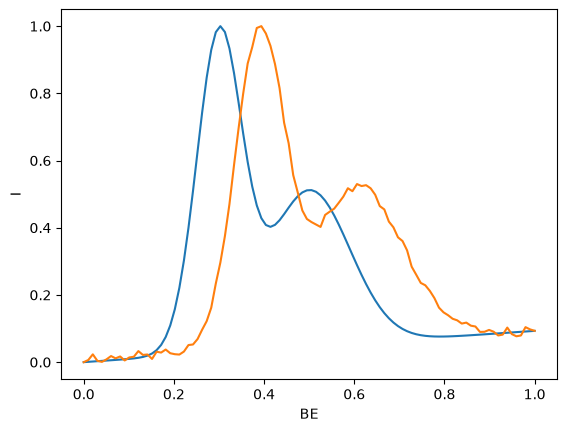

In [14]:
def plot_3_source_and_target_spectrum():
    pass

sampling = 2

sns.lineplot(spectra[sampling], x='BE', y='I')
sns.lineplot(spectra_variated[sampling], x='BE', y='I')

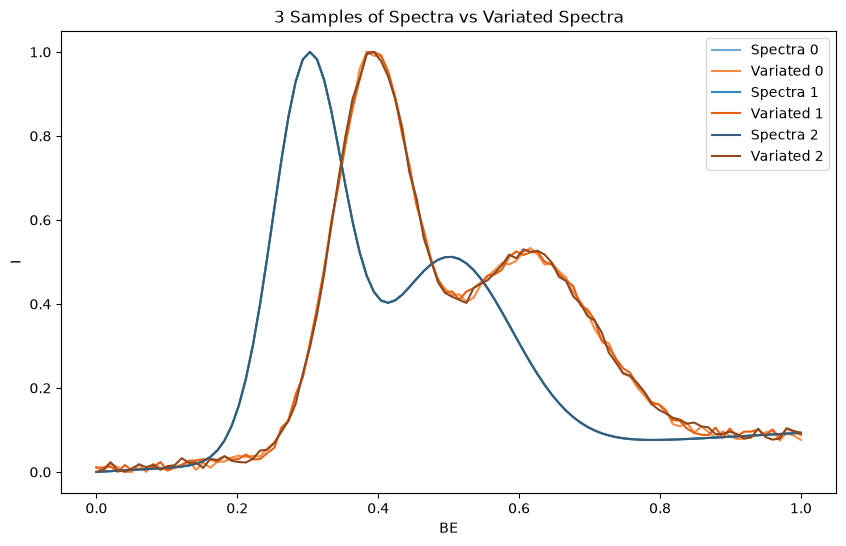

In [15]:
import matplotlib.pyplot as plt

colors_spectra = sns.color_palette("Blues_d", 3)
colors_variated = sns.color_palette("Oranges_d", 3)

plt.figure(figsize=(10, 6))

for i in range(3):
    sns.lineplot(data=spectra[i], x='BE', y='I', color=colors_spectra[i], label=f'Spectra {i}')
    sns.lineplot(data=spectra_variated[i], x='BE', y='I', color=colors_variated[i], label=f'Variated {i}')

plt.title("3 Samples of Spectra vs Variated Spectra")
plt.legend()
plt.show()

# Model

---


## Model Definition

In [16]:
model_defined = list()
model_parameters = dict()

### Basic CNN

In [17]:
model_name = 'model_CNN_basic'
model_defined.append(model_name)
model_parameters[model_name] =[
    {'in_channels': 1, 'out_channels': 3, 'kernel': 3, 'stride':1, 'padding': 0, 'padding_mode': 'zeros', 'dilation': 1}, # 1st CNN layer
    {'in_channels': 3, 'out_channels': 5, 'kernel': 3, 'stride':1, 'padding': 0, 'padding_mode': 'zeros', 'dilation': 1}, # 2nd CNN layer
    {'in_channels': 5, 'out_channels': 1, 'kernel': 3, 'stride':1, 'padding': 0, 'padding_mode': 'zeros', 'dilation': 1}, # 3rd CNN layer
]

class model_CNN_basic(nn.Module):
    def __init__(self, model_parameters):
        super().__init__()
        self.model_parameters = model_parameters
        # layer 0
        MP = self.model_parameters[0]
        self.cnn_layer0 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])
        self.batch_norm0 = nn.BatchNorm1d(MP['out_channels'])
        # layer 1
        MP = self.model_parameters[1]
        self.cnn_layer1 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])
        self.batch_norm1 = nn.BatchNorm1d(MP['out_channels'])
        # layer 2
        MP = self.model_parameters[2]
        self.cnn_layer2 = nn.Conv1d(MP['in_channels'], MP['out_channels'], MP['kernel'], MP['stride'], MP['padding'], MP['dilation'], 1, True, MP['padding_mode'])          
        self.batch_norm2 = nn.BatchNorm1d(MP['out_channels'])

    def forward(self, x):
        # layer 0
        x = self.cnn_layer0(x)
        x = self.batch_norm0(x)
        x = F.relu(x)
        # layer 1
        x = self.cnn_layer1(x)
        x = self.batch_norm1(x)
        x = F.relu(x)
        # layer 2
        x = self.cnn_layer2(x)
        x = self.batch_norm2(x)
        x = F.relu(x)
        return x
    
torchinfo.summary(model_CNN_basic(model_parameters['model_CNN_basic']), input_size=(100, 1, 100))

Layer (type:depth-idx)                   Output Shape              Param #
model_CNN_basic                          [100, 1, 94]              --
├─Conv1d: 1-1                            [100, 3, 98]              12
├─BatchNorm1d: 1-2                       [100, 3, 98]              6
├─Conv1d: 1-3                            [100, 5, 96]              50
├─BatchNorm1d: 1-4                       [100, 5, 96]              10
├─Conv1d: 1-5                            [100, 1, 94]              16
├─BatchNorm1d: 1-6                       [100, 1, 94]              2
Total params: 96
Trainable params: 96
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.75
Input size (MB): 0.04
Forward/backward pass size (MB): 1.39
Params size (MB): 0.00
Estimated Total Size (MB): 1.43

In [18]:
# # get all class name in current scope (useful for listing all defined models alter)
# import inspect

# class UserProfile: pass
# class OrderHistory: pass

# for name, obj in globals().items():
#     if inspect.isclass(obj) and obj.__module__ == __name__:
#         print(name)

### ResNet

In [19]:
model_defined.append('ResNet')

### ResNet + Global BE

### ResNet + Sliding Window

### ResNet + STN

### ResNet + Bayesian Optimization

ResNet + All

## Model Training

### Data refactoring

### Training

# Performance

---


## Cost

## Spectrum Comparison